> **3.1 Task 1: Bijection Learning**
> 
> Each sequence is derived from a new random bijection $\pi : \{1, \dots, V\} \to \{1, \dots, V\}$ with $V = 20$. At position $k$, the model has observed $k - 1$ distinct input–output pairs and must predict $\pi(x_k)$. Because inputs never repeat, the Bayes-optimal posterior over $\pi(x_k)$ is uniform over the $V - k + 1$ unseen values.
> 
> **Bayesian ground truth.** Let $O_{k-1}$ be observed outputs. Then
> 
> $$p(\pi(x_k) = y \mid \text{context}) = \begin{cases} \frac{1}{V-k+1}, & y \notin O_{k-1}, \\ 0, & y \in O_{k-1}, \end{cases}$$
> 
> with entropy $H_{\text{Bayes}}(k) = \log_2(V - k + 1)$.
> 
> **Evaluation.** We compute MAE over a held-out set of 2,000 bijections. Because $20! \approx 2.4 \times 10^{18}$ possible bijections exist and training uses only $10^5$ samples, no bijection is seen twice; the task enforces true hypothesis elimination.
> 
> **Sequence format.** Each training example is tokenized as
> 
> $$[x_1, y_1, \text{SEP}, x_2, y_2, \text{SEP}, \dots, x_{19}, \text{SEP}],$$
> 
> with teacher forcing at every $y_k$ position.


Let's build the dataset.

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from tqdm.autonotebook import tqdm

# --- 1. DATASET ---
class BijectionTask1(Dataset):
    def __init__(self, mappings, V=20):
        """
        mappings: A pre-generated tensor of shape (num_samples, V)
                  containing the specific bijections for this dataset.
        """
        self.mappings = mappings
        self.num_samples = mappings.shape[0]
        self.V = V
        self.staircase_entropy = torch.tensor([np.log2(V - k) for k in range(V - 1)], dtype=torch.float)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # 1. Fetch the exact 'Secret Rule' assigned to this sample
        # We put it in a 1-indexed tensor so we can look up y = mapping[x] easily
        mapping = torch.empty(self.V + 1, dtype=torch.long)
        mapping[1:] = self.mappings[idx]
        
        # 2. Randomize the presentation order of x
        x_order = torch.randperm(self.V)[:self.V - 1] + 1
        y_order = mapping[x_order]
        
        # 3. Interleave [x, y, SEP]
        seq = torch.zeros((self.V - 1) * 3, dtype=torch.long)
        seq[0::3] = x_order
        seq[1::3] = y_order
        # seq[2::3] is already 0 (SEP token)
        
        return {
            "input_ids": seq[:-1],
            "labels": seq[1:],
            "staircase": self.staircase_entropy
        }

# --- Utility to Generate Unseen Splits ---
def generate_disjoint_bijections(num_train, num_test, V=20):
    """
    Generates permutations for Train and Test simultaneously to guarantee
    we can track exactly what the model is learning.
    """
    total_needed = num_train + num_test
    # A fast way to generate millions of unique random permutations in PyTorch
    rand_vals = torch.rand(total_needed, V)
    all_mappings = torch.argsort(rand_vals, dim=1) + 1
    
    train_mappings = all_mappings[:num_train]
    test_mappings = all_mappings[num_train:]
    return train_mappings, test_mappings

# --- Verification ---
# Generate a tiny dummy split for verification
dummy_train, dummy_test = generate_disjoint_bijections(num_train=10, num_test=2, V=20)
task1_data = BijectionTask1(mappings=dummy_train, V=20)
first_sample = task1_data[0]

print("Sequence structure:", first_sample['input_ids'].tolist())
print("Staircase Entropy (bits per step):", [round(e, 3) for e in first_sample['staircase'].tolist()])

# --- Dataset Shape Analysis ---
print(f"Number of samples in train dataset: {len(task1_data)}")
print(f"Length of a single sequence (L): {first_sample['input_ids'].shape[0]} tokens")
print(f"Number of prediction steps (k): {first_sample['staircase'].shape[0]} steps")

Sequence structure: [10, 12, 0, 6, 1, 0, 12, 2, 0, 8, 16, 0, 18, 9, 0, 19, 4, 0, 1, 18, 0, 14, 13, 0, 16, 14, 0, 17, 10, 0, 13, 3, 0, 3, 19, 0, 15, 20, 0, 11, 7, 0, 2, 15, 0, 5, 5, 0, 20, 17, 0, 9, 8, 0, 7, 6]
Staircase Entropy (bits per step): [4.322, 4.248, 4.17, 4.087, 4.0, 3.907, 3.807, 3.7, 3.585, 3.459, 3.322, 3.17, 3.0, 2.807, 2.585, 2.322, 2.0, 1.585, 1.0]
Number of samples in train dataset: 10
Length of a single sequence (L): 56 tokens
Number of prediction steps (k): 19 steps


C:\Temp\ipykernel_4940\2295817243.py:6: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


### Dataset Dimensions & Metadata

1.  **`input_ids` shape: `[56]`**
    *   **Why 56?** We have 19 pairs. Each pair is 3 tokens (`x`, `y`, `SEP`). $19 \times 3 = 57$. We remove the last token (`SEP`) because there is nothing to predict after it. So, $57 - 1 = 56$.
2.  **`labels` shape: `[56]`**
    *   This is the same length as `input_ids`. It is shifted right by 1, so the model learns to predict the "next" token at every position.
3.  **`staircase` shape: `[19]`**
    *   This contains the 19 levels of uncertainty. 
    *   **Mapping:** The model's entropy at `input_ids` indices **0, 3, 6, 9...** (the positions of $x_1, x_2, x_3...$) should match these 19 values.

---

### 1. The Architecture (from Page 8, Section 3.5)

> **Bijection transformer (2.67M):** 6 layers, 6 heads, $d_{model} = 192$, $d_{ffn} = 768$.
> 
> Both use learned token embeddings, learned absolute positional embeddings, pre-norm residual blocks, and standard multi-head self-attention.

### 2. The Training Protocol (from Page 9, Section 3.6)

> **Optimization.** AdamW with $\beta_1 = 0.9, \beta_2 = 0.999$, weight decay 0.01, gradient clipping at 1.0. Batch size is 64 for all tasks.
> 
> **Learning rates and training steps.**
> * **Bijections:** constant $10^{-3}$ for 150k steps.
> 
> **Data sampling.** Every batch draws fresh bijections or fresh HMMs; sequences never repeat.
> 
> **Teacher forcing.** Cross-entropy loss is applied at each supervised prediction position.

In [10]:
# --- HYPERPARAMETERS (Section 3.5 & 3.6) ---
V = 20
VOCAB_SIZE = 21   # 1-20 + SEP token (0)
D_MODEL = 192
NHEAD = 6
NUM_LAYERS = 6
D_FFN = 768
MAX_SEQ_LEN = 56  # (19 pairs * 3 tokens) - 1

BATCH_SIZE = 64
LR = 1.5e-3         # OG: 1e-3
STEPS = 9000      # OG: 150k 
MONITOR_INTERVAL = 100

TEST_SAMPLES = 2000 # As per paper for the evaluation

WEIGHT_DECAY = 0.01
CLIP = 1.0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --- 2. MODEL DEFINITION ---
class BijectionTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding = nn.Embedding(VOCAB_SIZE, D_MODEL)
        self.pos_embedding = nn.Parameter(torch.zeros(1, MAX_SEQ_LEN, D_MODEL))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, nhead=NHEAD, dim_feedforward=D_FFN,
            dropout=0.0, activation='gelu', batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=NUM_LAYERS, enable_nested_tensor=False
        )
        self.ln_f = nn.LayerNorm(D_MODEL)
        self.head = nn.Linear(D_MODEL, VOCAB_SIZE, bias=False)

    def forward(self, x):
        b, t = x.size()
        x = self.token_embedding(x) + self.pos_embedding[:, :t, :]
        mask = torch.triu(torch.ones(t, t, device=x.device) * float('-inf'), diagonal=1)
        x = self.transformer(x, mask=mask, is_causal=True)
        return self.head(self.ln_f(x))

# --- 3. EXPERIMENTAL SETUP (Strict Split) ---
print(f"Pre-generating disjoint Train ({STEPS * BATCH_SIZE}) and Test ({TEST_SAMPLES}) splits...")
train_mappings, test_mappings = generate_disjoint_bijections(num_train=STEPS * BATCH_SIZE, num_test=TEST_SAMPLES, V=V)

train_dataset = BijectionTask1(mappings=train_mappings, V=V)
# We will use this test_dataset in Cell 3 later!
test_dataset = BijectionTask1(mappings=test_mappings, V=V) 

loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)

model = BijectionTransformer().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999), fused=torch.cuda.is_available())

def get_predictive_entropy(logits):
    probs = F.softmax(logits, dim=-1)
    log_probs = F.log_softmax(logits, dim=-1)
    return -(probs * log_probs).sum(dim=-1) / np.log(2)

Y_POSITIONS = torch.arange(0, MAX_SEQ_LEN, 3, device=DEVICE)

# --- 4. TRAINING LOOP ---
print(f"Starting training on {DEVICE}...")
model.train()

pbar = tqdm(loader, total=STEPS, desc="Training")
for step, batch in enumerate(pbar):
    if step >= STEPS: break
    
    inputs = batch['input_ids'].to(DEVICE, non_blocking=True)
    targets = batch['labels'].to(DEVICE, non_blocking=True)
    
    logits = model(inputs)
    
    loss = F.cross_entropy(logits[:, Y_POSITIONS, :].reshape(-1, VOCAB_SIZE), targets[:, Y_POSITIONS].reshape(-1))
    
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
    optimizer.step()

    # --- MONITORING ---
    if step % MONITOR_INTERVAL == 0:
        with torch.no_grad():
            ideal_staircase = batch['staircase'].to(DEVICE, non_blocking=True)[0]
            model_entropy = get_predictive_entropy(logits[0, Y_POSITIONS, :])
            mae = torch.abs(model_entropy - ideal_staircase).mean().item()
            pbar.set_postfix({"Loss": f"{loss.item():.4f}", "MAE (bits)": f"{mae:.4f}"})

print("Training Complete.")

Pre-generating disjoint Train (576000) and Test (2000) splits...
Starting training on cuda...


Training: 100%|██████████| 9000/9000 [09:35<00:00, 15.63it/s, Loss=2.2484, MAE (bits)=0.0200]

Training Complete.


Evaluating on 2000 strictly unseen bijections...
Final Test MAE: 0.0239 bits
Plot successfully saved to: results\bijection_task1_staircase.pdf


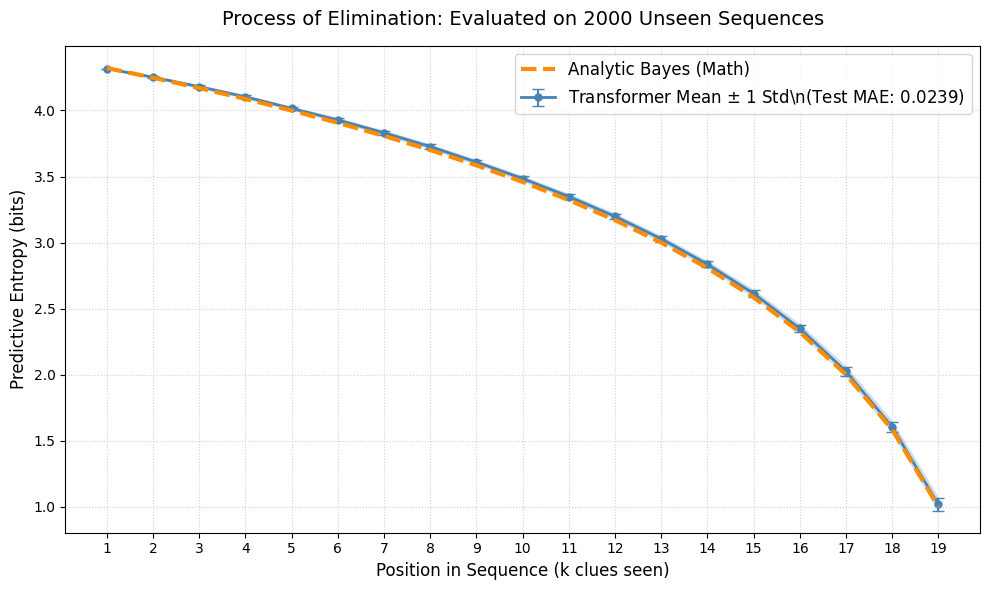

In [11]:
import os
import matplotlib.pyplot as plt

# --- 1. EVALUATION (Full Test Set) ---
print(f"Evaluating on {len(test_dataset)} strictly unseen bijections...")

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=0)

model.eval()
total_mae = 0.0
all_predictions = [] 

with torch.no_grad():
    for batch in test_loader:
        inputs = batch['input_ids'].to(DEVICE)
        ideal_staircase = batch['staircase'].to(DEVICE)
        
        logits = model(inputs)
        model_entropy = get_predictive_entropy(logits[:, Y_POSITIONS, :])
        
        batch_mae = torch.abs(model_entropy - ideal_staircase).mean().item()
        total_mae += batch_mae * inputs.size(0) 
        
        all_predictions.append(model_entropy.cpu())

all_predictions_tensor = torch.cat(all_predictions, dim=0)

mean_entropy = all_predictions_tensor.mean(dim=0).numpy()
std_entropy = all_predictions_tensor.std(dim=0).numpy()

final_mae = total_mae / len(test_dataset)
print(f"Final Test MAE: {final_mae:.4f} bits")

# --- 2. PLOT THE STATISTICAL STAIRCASE ---
ideal_staircase_np = test_dataset[0]['staircase'].numpy()
k_steps = np.arange(1, len(ideal_staircase_np) + 1)

plt.figure(figsize=(10, 6))

plt.plot(k_steps, ideal_staircase_np, 
         label="Analytic Bayes (Math)", 
         color='darkorange', linestyle='--', linewidth=3, zorder=3)

plt.errorbar(k_steps, mean_entropy, yerr=std_entropy, 
             label=fr"Transformer Mean $\pm$ 1 Std\n(Test MAE: {final_mae:.4f})", 
             color='steelblue', marker='o', linewidth=2, markersize=5, 
             capsize=4, elinewidth=1.5, zorder=2)

plt.fill_between(k_steps, mean_entropy - std_entropy, mean_entropy + std_entropy, 
                 color='steelblue', alpha=0.2, zorder=1)

plt.title(f"Process of Elimination: Evaluated on {len(test_dataset)} Unseen Sequences", fontsize=14, pad=15)
plt.xlabel("Position in Sequence (k clues seen)", fontsize=12)
plt.ylabel("Predictive Entropy (bits)", fontsize=12)
plt.xticks(k_steps)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12)

plt.tight_layout()

# --- 3. SAVE THE PLOT ---
# Create the results directory if it doesn't exist
output_dir = "results"
os.makedirs(output_dir, exist_ok=True)

# Save as PDF
file_path = os.path.join(output_dir, "bijection_task1_staircase.pdf")
plt.savefig(file_path, format='pdf', bbox_inches='tight')
print(f"Plot successfully saved to: {file_path}")

# Display the plot in the notebook
plt.show()

The paper claims that in the very first layer, the Transformer creates a literal geometric coordinate system. It takes the 20 possible symbols and spaces them out so they are at 90-degree angles (orthogonal) to each other, creating a clean "Hypothesis Frame."

### From Pages 14-15 (Section 5.1: Layer 0 Creates the Hypothesis Frame)

> The computation begins with a structural operation: Layer 0 attention constructs the *hypothesis space* in which all subsequent inference takes place. Keys at this layer form an approximately orthogonal basis over input tokens (Figure 16), providing a coordinate system over which posterior mass can be represented and manipulated. We measure orthogonality via mean absolute off-diagonal cosine similarity between key vectors.

--- Uncovering the Hidden Hypothesis Geometry ---
Layer 0, Head 0 Orthogonality: 0.3112
Layer 0, Head 1 Orthogonality: 0.2742
Layer 0, Head 2 Orthogonality: 0.3623
Layer 0, Head 3 Orthogonality: 0.2753
Layer 0, Head 4 Orthogonality: 0.2623
Layer 0, Head 5 Orthogonality: 0.2421

Best Hypothesis Head in Layer 0 has score: 0.2421


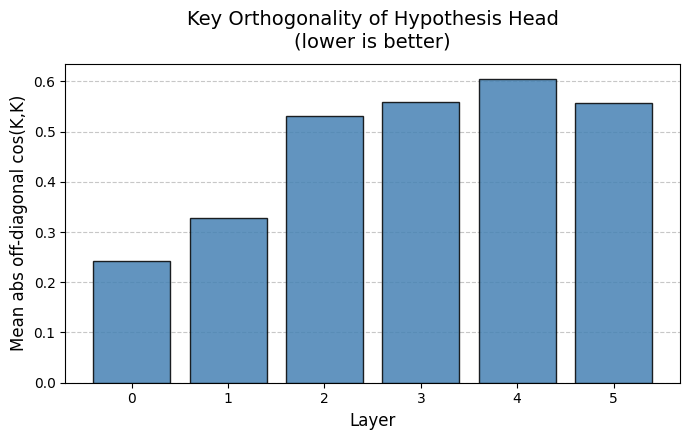

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import os

model.eval()
layer_best_sims = []

print("--- Uncovering the Hidden Hypothesis Geometry ---")

with torch.no_grad():
    # 1. Isolated tokens (1 to 20). No sequence context.
    tokens = torch.arange(1, V + 1, device=DEVICE).unsqueeze(1) 
    
    # Do NOT add pos_embedding. We want the pure semantic token geometry.
    h = model.token_embedding(tokens) 

    for i, layer in enumerate(model.transformer.layers):
        
        # Extract weights
        in_proj_weight = layer.self_attn.in_proj_weight
        in_proj_bias = layer.self_attn.in_proj_bias
        _, k_weight, _ = in_proj_weight.chunk(3, dim=0)
        _, k_bias, _ = in_proj_bias.chunk(3, dim=0)
        
        # Apply LayerNorm
        h_norm = layer.norm1(h).squeeze(1) 
        
        # Compute Keys
        K_full = F.linear(h_norm, k_weight, k_bias) 
        
        # Split into 6 Heads (Shape: [20, 6, 32])
        HEAD_DIM = D_MODEL // NHEAD
        K_heads = K_full.view(V, NHEAD, HEAD_DIM)
        
        best_head_sim = float('inf')
        
        for head_idx in range(NHEAD):
            # Extract the 32-dim Key vector for this head
            K_h = K_heads[:, head_idx, :]
            
            # --- THE FIX: MEAN CENTERING ---
            # Strip away the massive shared constant vector to reveal the true angles
            K_h_centered = K_h - K_h.mean(dim=0, keepdim=True)
            
            # Normalize and compute Cosine Similarity
            K_h_norm = F.normalize(K_h_centered, p=2, dim=-1)
            cos_sim_matrix = torch.matmul(K_h_norm, K_h_norm.T).cpu().numpy()
            
            # Compute Mean Absolute Off-Diagonal
            mask = ~np.eye(V, dtype=bool)
            mean_off_diag = np.abs(cos_sim_matrix[mask]).mean()
            
            if i == 0:
                print(f"Layer 0, Head {head_idx} Orthogonality: {mean_off_diag:.4f}")
            
            # Track the most orthogonal head (lowest score)
            if mean_off_diag < best_head_sim:
                best_head_sim = mean_off_diag
                
        layer_best_sims.append(best_head_sim)
        
        # Forward pass through the rest of the layer
        h = layer(h)

print(f"\nBest Hypothesis Head in Layer 0 has score: {layer_best_sims[0]:.4f}")

# --- PLOT FIGURE 16 ---
layers = np.arange(NUM_LAYERS)

plt.figure(figsize=(7, 4.5))

plt.bar(layers, layer_best_sims, color='steelblue', edgecolor='black', alpha=0.85, zorder=3)

plt.title("Key Orthogonality of Hypothesis Head\n(lower is better)", fontsize=14, pad=12)
plt.xlabel("Layer", fontsize=12)
plt.ylabel("Mean abs off-diagonal cos(K,K)", fontsize=12)
plt.xticks(layers)
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

output_dir = "results"
os.makedirs(output_dir, exist_ok=True)
file_path = os.path.join(output_dir, "fig16_key_orthogonality.pdf")
plt.savefig(file_path, format='pdf', bbox_inches='tight')

plt.tight_layout()
plt.show()

### Next Step: Figure 17 (Progressive Q-K Sharpening)
Now that we have proven Layer 0 builds the frame, we need to prove that the middle layers actually do the "Process of Elimination." 

On **Page 18 (Section 5.2)**, the paper says:
> *"As depth increases, queries align more strongly with the subset of keys consistent with the observed evidence... Early layers attend broadly; deeper layers concentrate attention almost exclusively on the feasible hypotheses. This geometric focusing parallels analytic Bayesian conditioning..."*

To prove this, we are going to extract the **Queries (Q)** and **Keys (K)** from a real sequence as it passes through the model. We will plot the Q-K alignment for Layer 0 (which should look blurry/diffuse) and Layer 5 (which should be razor-sharp, eliminating the wrong answers).

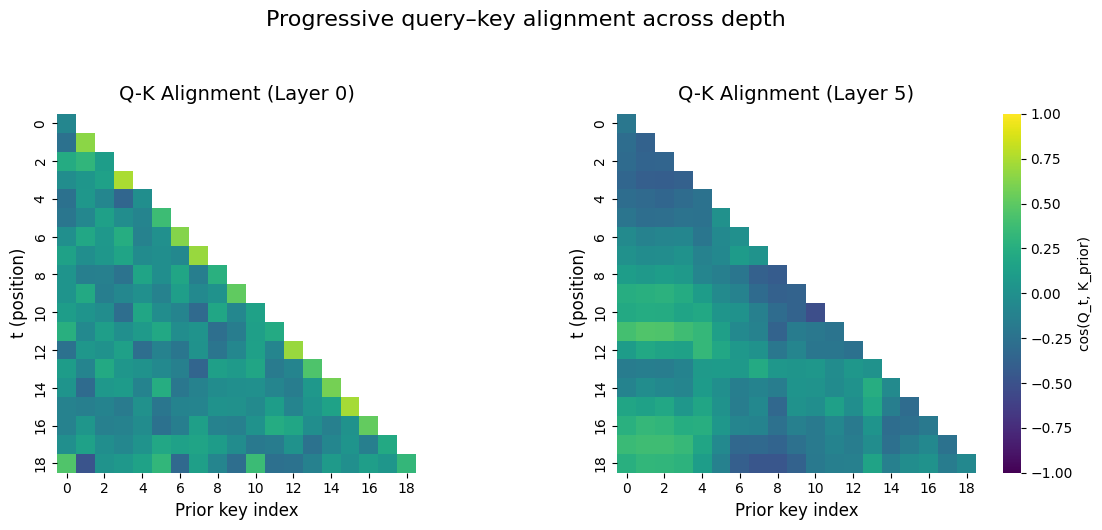

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model.eval()
qk_matrices = {}

with torch.no_grad():
    # 1. Grab one sequence from the test set
    sample_seq = test_dataset[0]['input_ids'].unsqueeze(0).to(DEVICE) 
    seq_len = sample_seq.size(1)
    
    h = model.token_embedding(sample_seq) + model.pos_embedding[:, :seq_len, :]
    
    # We extract Q and K at the 19 prediction positions (x_k)
    query_positions = torch.arange(0, seq_len, 3, device=DEVICE)
    
    for i, layer in enumerate(model.transformer.layers):
        
        # Get Q and K weights
        in_proj_weight = layer.self_attn.in_proj_weight
        in_proj_bias = layer.self_attn.in_proj_bias
        q_weight, k_weight, _ = in_proj_weight.chunk(3, dim=0)
        q_bias, k_bias, _ = in_proj_bias.chunk(3, dim=0)
        
        # Apply Pre-norm
        h_norm = layer.norm1(h)
        
        # Compute Q and K for the sequence
        Q_full = F.linear(h_norm, q_weight, q_bias)
        K_full = F.linear(h_norm, k_weight, k_bias)
        
        # Reshape to heads: [SeqLen, 6, 32]
        HEAD_DIM = D_MODEL // NHEAD
        Q_heads = Q_full.view(1, seq_len, NHEAD, HEAD_DIM)[0]
        K_heads = K_full.view(1, seq_len, NHEAD, HEAD_DIM)[0]
        
        # Isolate the 19 prediction steps
        Q_t = Q_heads[query_positions] # Shape: [19, 6, 32]
        K_t = K_heads[query_positions] # Shape: [19, 6, 32]
        
        # --- THE FIX: Mean-Center to strip the Softmax bias ---
        Q_t = Q_t - Q_t.mean(dim=0, keepdim=True)
        K_t = K_t - K_t.mean(dim=0, keepdim=True)
        
        # Normalize
        Q_norm = F.normalize(Q_t, p=2, dim=-1)
        K_norm = F.normalize(K_t, p=2, dim=-1)
        
        # Compute Cosine Sim for all 6 heads simultaneously
        # Result shape: [6 heads, 19 queries, 19 keys]
        sim_heads = torch.einsum('ihd,jhd->hij', Q_norm, K_norm)
        
        # --- THE FIX: Average across all heads ---
        sim_matrix = sim_heads.mean(dim=0).cpu().numpy()
        
        # Apply Causal Mask (Queries cannot look at future Keys)
        mask = np.triu(np.ones_like(sim_matrix, dtype=bool), k=1)
        sim_matrix[mask] = np.nan 
        
        qk_matrices[i] = sim_matrix
        
        # Forward pass to next layer
        mask_fwd = torch.triu(torch.ones(seq_len, seq_len, device=DEVICE) * float('-inf'), diagonal=1)
        h = layer(h, src_mask=mask_fwd)

# --- 3. PLOT FIGURE 17 (Layer 0 vs Layer 5) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cmap = "viridis"
vmax = 1.0
vmin = -1.0

# Layer 0 Plot
sns.heatmap(qk_matrices[0], ax=axes[0], cmap=cmap, vmin=vmin, vmax=vmax, 
            cbar=False, square=True, xticklabels=2, yticklabels=2)
axes[0].set_title("Q-K Alignment (Layer 0)", fontsize=14, pad=10)
axes[0].set_xlabel("Prior key index", fontsize=12)
axes[0].set_ylabel("t (position)", fontsize=12)
axes[0].set_facecolor('white')

# Layer 5 Plot
im = sns.heatmap(qk_matrices[NUM_LAYERS-1], ax=axes[1], cmap=cmap, vmin=vmin, vmax=vmax, 
                 cbar=True, square=True, xticklabels=2, yticklabels=2, 
                 cbar_kws={'label': 'cos(Q_t, K_prior)'})
axes[1].set_title(f"Q-K Alignment (Layer {NUM_LAYERS-1})", fontsize=14, pad=10)
axes[1].set_xlabel("Prior key index", fontsize=12)
axes[1].set_ylabel("t (position)", fontsize=12)
axes[1].set_facecolor('white')

plt.suptitle("Progressive query–key alignment across depth", fontsize=16, y=1.05)
plt.tight_layout()

file_path = os.path.join(output_dir, "fig17_qk_sharpening.pdf")
plt.savefig(file_path, format='pdf', bbox_inches='tight')
plt.show()

--- 1. Training 2-Layer Transformer for 25000 steps ---


Training 2-Layer: 100%|██████████| 25000/25000 [09:24<00:00, 44.26it/s, Loss=2.2411, MAE=0.0171]



--- 2. Evaluating on Unseen Test Set ---


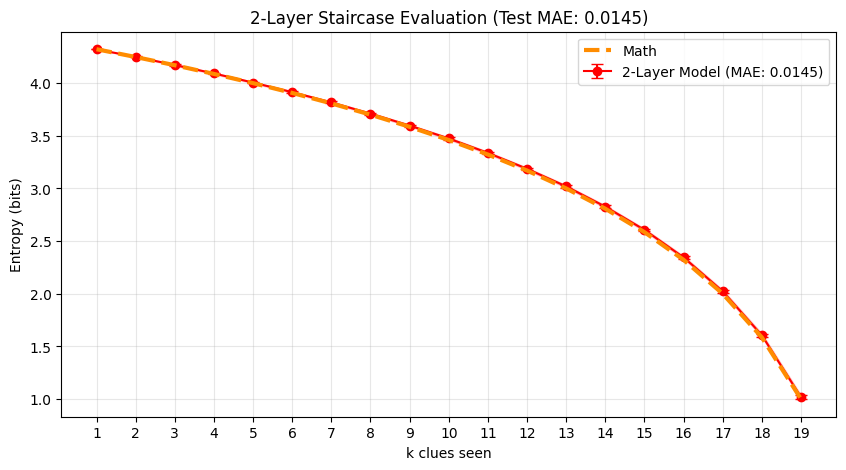


--- 3. Extracting Key Orthogonality (Fig 16) ---


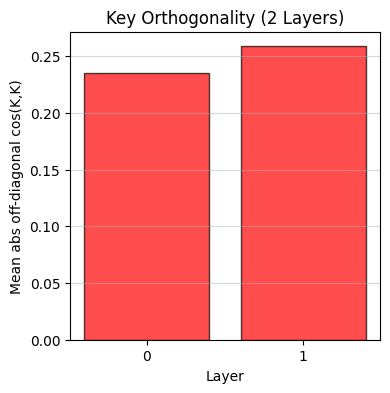


--- 4. Extracting QK Sharpening (Fig 17) ---


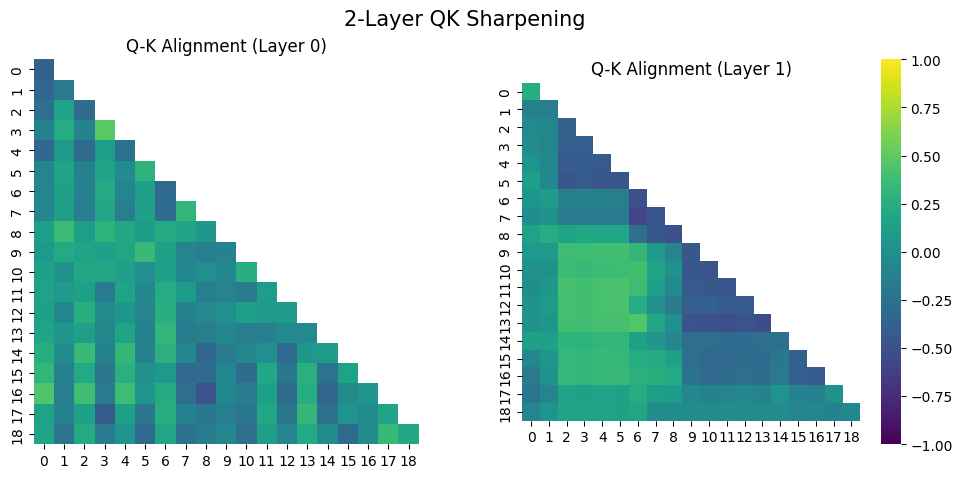

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.autonotebook import tqdm
import os

# --- 1. MINI-MODEL CONFIGURATION ---
V = 20
VOCAB_SIZE = 21   
D_MODEL = 192
NHEAD = 6
D_FFN = 768
MAX_SEQ_LEN = 56  

# Modified for the extreme shrink test
NUM_LAYERS_MINI = 2
STEPS_MINI = 25000
LR_MINI = 1.5e-3
MONITOR_INTERVAL = 200

BATCH_SIZE = 64
TEST_SAMPLES = 2000
WEIGHT_DECAY = 0.01
CLIP = 1.0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
Y_POSITIONS = torch.arange(0, MAX_SEQ_LEN, 3, device=DEVICE)

print(f"--- 1. Training 2-Layer Transformer for {STEPS_MINI} steps ---")

class MiniBijectionTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding = nn.Embedding(VOCAB_SIZE, D_MODEL)
        self.pos_embedding = nn.Parameter(torch.zeros(1, MAX_SEQ_LEN, D_MODEL))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, nhead=NHEAD, dim_feedforward=D_FFN,
            dropout=0.0, activation='gelu', batch_first=True, norm_first=True
        )
        # FORCE 2 LAYERS
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=NUM_LAYERS_MINI, enable_nested_tensor=False)
        self.ln_f = nn.LayerNorm(D_MODEL)
        self.head = nn.Linear(D_MODEL, VOCAB_SIZE, bias=False)

    def forward(self, x):
        b, t = x.size()
        x = self.token_embedding(x) + self.pos_embedding[:, :t, :]
        mask = torch.triu(torch.ones(t, t, device=x.device) * float('-inf'), diagonal=1)
        x = self.transformer(x, mask=mask, is_causal=True)
        return self.head(self.ln_f(x))

# Generate fresh data splits to ensure integrity
train_maps_mini, test_maps_mini = generate_disjoint_bijections(STEPS_MINI * BATCH_SIZE, TEST_SAMPLES, V)
train_ds_mini = BijectionTask1(mappings=train_maps_mini, V=V)
test_ds_mini = BijectionTask1(mappings=test_maps_mini, V=V)

train_loader_mini = DataLoader(train_ds_mini, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
test_loader_mini = DataLoader(test_ds_mini, batch_size=BATCH_SIZE, num_workers=0)

model_mini = MiniBijectionTransformer().to(DEVICE)
optimizer_mini = torch.optim.AdamW(model_mini.parameters(), lr=LR_MINI, weight_decay=WEIGHT_DECAY, fused=torch.cuda.is_available())

# --- TRACKING SETUP ---
def get_predictive_entropy(logits):
    probs = F.softmax(logits, dim=-1)
    log_probs = F.log_softmax(logits, dim=-1)
    return -(probs * log_probs).sum(dim=-1) / np.log(2)


model_mini.train()
pbar = tqdm(train_loader_mini, total=STEPS_MINI, desc="Training 2-Layer")
for step, batch in enumerate(pbar):
    if step >= STEPS_MINI: break
    
    inputs = batch['input_ids'].to(DEVICE, non_blocking=True)
    targets = batch['labels'].to(DEVICE, non_blocking=True)
    
    logits = model_mini(inputs)
    
    loss = F.cross_entropy(logits[:, Y_POSITIONS, :].reshape(-1, VOCAB_SIZE), targets[:, Y_POSITIONS].reshape(-1))
    
    optimizer_mini.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_mini.parameters(), CLIP)
    optimizer_mini.step()
    
    # --- RESTORED REAL-TIME MONITORING ---
    if step % MONITOR_INTERVAL == 0:
        with torch.no_grad():
            ideal_staircase = batch['staircase'].to(DEVICE, non_blocking=True)[0]
            model_entropy = get_predictive_entropy(logits[0, Y_POSITIONS, :])
            mae = torch.abs(model_entropy - ideal_staircase).mean().item()
            
            pbar.set_postfix({"Loss": f"{loss.item():.4f}", "MAE": f"{mae:.4f}"})


# --- 2. PLOT 1: THE STAIRCASE EVALUATION ---
print("\n--- 2. Evaluating on Unseen Test Set ---")
model_mini.eval()
all_predictions = []
total_mae = 0.0

with torch.no_grad():
    for batch in test_loader_mini:
        inputs, ideal_staircase = batch['input_ids'].to(DEVICE), batch['staircase'].to(DEVICE)
        logits = model_mini(inputs)
        model_entropy = get_predictive_entropy(logits[:, Y_POSITIONS, :])
        batch_mae = torch.abs(model_entropy - ideal_staircase).mean().item()
        total_mae += batch_mae * inputs.size(0)
        all_predictions.append(model_entropy.cpu())

all_preds_tensor = torch.cat(all_predictions, dim=0)
mean_ent, std_ent = all_preds_tensor.mean(dim=0).numpy(), all_preds_tensor.std(dim=0).numpy()
final_mae = total_mae / len(test_ds_mini)
ideal_np = test_ds_mini[0]['staircase'].numpy()
k_steps = np.arange(1, len(ideal_np) + 1)

plt.figure(figsize=(10, 5))
plt.plot(k_steps, ideal_np, label="Math", color='darkorange', linestyle='--', linewidth=3, zorder=3)
plt.errorbar(k_steps, mean_ent, yerr=std_ent, label=f"2-Layer Model (MAE: {final_mae:.4f})", 
             color='red', marker='o', capsize=4, zorder=2)
plt.fill_between(k_steps, mean_ent - std_ent, mean_ent + std_ent, color='red', alpha=0.2, zorder=1)
plt.title(f"2-Layer Staircase Evaluation (Test MAE: {final_mae:.4f})")
plt.xlabel("k clues seen"); plt.ylabel("Entropy (bits)"); plt.xticks(k_steps); plt.grid(alpha=0.3); plt.legend()
plt.show()

# --- 3. PLOT 2: FIGURE 16 (KEY ORTHOGONALITY) ---
print("\n--- 3. Extracting Key Orthogonality (Fig 16) ---")
layer_best_sims = []
with torch.no_grad():
    tokens = torch.arange(1, V + 1, device=DEVICE).unsqueeze(1) 
    h = model_mini.token_embedding(tokens) 
    for i, layer in enumerate(model_mini.transformer.layers):
        in_proj_weight, in_proj_bias = layer.self_attn.in_proj_weight, layer.self_attn.in_proj_bias
        _, k_weight, _ = in_proj_weight.chunk(3, dim=0)
        _, k_bias, _ = in_proj_bias.chunk(3, dim=0)
        
        h_norm = layer.norm1(h).squeeze(1) 
        K_full = F.linear(h_norm, k_weight, k_bias) 
        K_heads = K_full.view(V, NHEAD, D_MODEL // NHEAD)
        
        best_head_sim = float('inf')
        for head_idx in range(NHEAD):
            K_h = K_heads[:, head_idx, :]
            K_h_centered = K_h - K_h.mean(dim=0, keepdim=True)
            K_h_norm = F.normalize(K_h_centered, p=2, dim=-1)
            sim_matrix = torch.matmul(K_h_norm, K_h_norm.T).cpu().numpy()
            mean_off_diag = np.abs(sim_matrix[~np.eye(V, dtype=bool)]).mean()
            if mean_off_diag < best_head_sim: best_head_sim = mean_off_diag
        layer_best_sims.append(best_head_sim)
        h = layer(h)

plt.figure(figsize=(4, 4))
plt.bar([0, 1], layer_best_sims, color='red', edgecolor='black', alpha=0.7)
plt.title("Key Orthogonality (2 Layers)")
plt.xlabel("Layer"); plt.ylabel("Mean abs off-diagonal cos(K,K)"); plt.xticks([0, 1]); plt.grid(axis='y', alpha=0.5)
plt.show()

# --- 4. PLOT 3: FIGURE 17 (QK SHARPENING) ---
print("\n--- 4. Extracting QK Sharpening (Fig 17) ---")
qk_matrices = {}
with torch.no_grad():
    sample_seq = test_ds_mini[0]['input_ids'].unsqueeze(0).to(DEVICE) 
    seq_len = sample_seq.size(1)
    h = model_mini.token_embedding(sample_seq) + model_mini.pos_embedding[:, :seq_len, :]
    query_positions = torch.arange(0, seq_len, 3, device=DEVICE)
    
    for i, layer in enumerate(model_mini.transformer.layers):
        in_proj_weight, in_proj_bias = layer.self_attn.in_proj_weight, layer.self_attn.in_proj_bias
        q_weight, k_weight, _ = in_proj_weight.chunk(3, dim=0)
        q_bias, k_bias, _ = in_proj_bias.chunk(3, dim=0)
        
        h_norm = layer.norm1(h)
        Q_full, K_full = F.linear(h_norm, q_weight, q_bias), F.linear(h_norm, k_weight, k_bias)
        Q_heads = Q_full.view(1, seq_len, NHEAD, D_MODEL // NHEAD)[0]
        K_heads = K_full.view(1, seq_len, NHEAD, D_MODEL // NHEAD)[0]
        
        Q_t, K_t = Q_heads[query_positions], K_heads[query_positions]
        Q_t = Q_t - Q_t.mean(dim=0, keepdim=True)
        K_t = K_t - K_t.mean(dim=0, keepdim=True)
        
        Q_norm, K_norm = F.normalize(Q_t, p=2, dim=-1), F.normalize(K_t, p=2, dim=-1)
        sim_matrix = torch.einsum('ihd,jhd->hij', Q_norm, K_norm).mean(dim=0).cpu().numpy()
        
        mask = np.triu(np.ones_like(sim_matrix, dtype=bool), k=1)
        sim_matrix[mask] = np.nan 
        qk_matrices[i] = sim_matrix
        
        h = layer(h, src_mask=torch.triu(torch.ones(seq_len, seq_len, device=DEVICE) * float('-inf'), diagonal=1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(qk_matrices[0], ax=axes[0], cmap="viridis", vmin=-1.0, vmax=1.0, cbar=False, square=True)
axes[0].set_title("Q-K Alignment (Layer 0)")
sns.heatmap(qk_matrices[1], ax=axes[1], cmap="viridis", vmin=-1.0, vmax=1.0, cbar=True, square=True)
axes[1].set_title("Q-K Alignment (Layer 1)")
plt.suptitle("2-Layer QK Sharpening", fontsize=15)
plt.show()